In [7]:
from sage.all import *
k=4
levels=[]
for N in range(1, 15):
    try:
        nf = Newforms(N, k, names='a')
        if len(nf)>0:
            levels.append((N,len(nf)))
    except Exception:
        pass
if levels!=[]:
    for pair in levels:
        print(pair)

(5, 1)
(6, 1)
(7, 1)
(8, 1)
(9, 1)
(10, 1)
(11, 1)
(12, 1)
(13, 2)
(14, 2)


In [18]:
k, N = 4, 11
nf = Newforms(N, k, names='a')
for index in range(0,len(nf)):
    print("index:",index)
    f = nf[index]
    expansion = f.q_expansion(401)
    coeffs = [expansion[n] for n in range(1, 401)]
    print(coeffs[:20])
    print()


index: 0
[1, a0, -4*a0 + 3, 2*a0 - 6, 8*a0 - 7, -5*a0 - 8, -4*a0 + 14, -10*a0 + 4, 8*a0 + 14, 9*a0 + 16, -11, 14*a0 - 34, -20*a0 + 60, 6*a0 - 8, -12*a0 - 85, -32*a0 + 28, 12*a0 - 74, 30*a0 + 16, 60*a0 - 24, -30*a0 + 74]



In [17]:
S = CuspForms(11, 4)
f = S.newforms(names='a')[0]
K = f.base_ring()
poly = K.polynomial()
print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators

[-sqrt(3) + 1, sqrt(3) + 1]


In [ ]:
``In what sense do these generators generate the field?

``In the sense that every element of the field Q(a0) can be written as a polynomial in a0 with rational coefficients. That is, every element has the form
\[
c_0 + c_1 a_0 + c_2 a_0^2 + \cdots + c_{d-1} a_0^{d-1}
\]
where c0,c1,…,cd−1∈Q and 
d is the degree of the minimal polynomial. The minimal polynomial is what allows you to reduce any higher power of a0 back down to degree less than dd
d --- for example in the weight-4 level-11 case, a02=2a0+2a_0^2 = 2a_0 + 2
a02​=2a0​+2, so nothing of degree 2 or higher ever appears irreducibly.

So the field is just Q extended by one algebraic number a_0
and that single number is enough to reach everything in the field by rational arithmetic operations.


In [17]:
# this inputs level as N, weight as k, desired dinensjon as dim and finds those N such 
# that fit the description.
from sage.all import *
k = 4
dim = 3
lst=[]

for N in range(1, 500):
    S = CuspForms(N, k)
    d = S.dimension()
    if d ==dim:
        lst.append(N)
print(lst)

[10, 12, 13, 16]


In [6]:
S = CuspForms(10, 4)
f = S.newforms(names='a')[0]
K = f.base_ring()
poly = K.polynomial()
print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators
print(K.degree())

[0]
1


In [22]:
from sage.all import *
k = 4
dim = 3
lst=[]

for N in range(1, 500):
    S = CuspForms(N, k)
    d = S.dimension()
    if d ==dim:
        lst.append(N)
print(lst)
S = CuspForms(10, 4)
for f in S.newforms():
    K = f.base_ring()
    poly = K.polynomial()
    print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators
    print(K.degree())

[10, 12, 13, 16]
[0]
1


In [5]:
from sage.all import *
lst=[]
precision = 10
k=4
print("prime N's:",primes_first_n(100))
for N in primes_first_n(100): 
    S = CuspForms(N, k)
    d = S.dimension()
    print("*****************************************************************************************")
    print("(N,k):",(N,k),"dimension CuspForms(N,k):",d)

prime N's: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503, 509, 521, 523, 541]
*****************************************************************************************
(N,k): (2, 4) dimension CuspForms(N,k): 0
*****************************************************************************************
(N,k): (3, 4) dimension CuspForms(N,k): 0
*****************************************************************************************
(N,k): (5, 4) dimension CuspForms(N,k): 1
*****************************************************************************************
(N,k): (7, 4) dimension CuspFor

In [7]:
from sage.all import *
lst=[]
precision = 10
N=5
k=4
S = CuspForms(N, k)
d = S.dimension()
print("*****************************************************************************************")
print("(N,k):",(N,k),"dimension CuspForms(N,k):",d)
S = CuspForms(N,k)
print("For the CuspForms(N,k), echelon basis:")
for f in S.basis():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("basis member:")
    print(f.q_expansion(precision))
    Ks = f.base_ring()
    print("field of coefficients Ks of the echelon basis member in CuspForms(N,k):",   Ks)
    print("[Ks:Q]:",Ks.degree())
    print("field polynomial:")
    poly = Ks.polynomial()
    print(poly)
    print("roots:")
    print(poly.roots(ring=SR, multiplicities=False)) 
    print("-------------------------------------------------------------------------")
    print("For the CuspForms(N,k) eigenbasis (let a vary over the root set):")
for f in S.newforms(names='a'):
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("basis member:")
    print(f.q_expansion(precision))
    Ke = f.base_ring()
    print("field of coefficients Ke of the eigenbasis member in CuspForms(N,k):",Ke)
    print("[Ke:Q]:",Ke.degree())
    print("field polynomial:")
    poly = Ke.polynomial()
    print(poly)
    print("roots:")
    print(poly.roots(ring=SR, multiplicities=False))

*****************************************************************************************
(N,k): (5, 4) dimension CuspForms(N,k): 1
For the CuspForms(N,k), echelon basis:
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
basis member:
q - 4*q^2 + 2*q^3 + 8*q^4 - 5*q^5 - 8*q^6 + 6*q^7 - 23*q^9 + O(q^10)
field of coefficients Ks of the echelon basis member in CuspForms(N,k): Rational Field
[Ks:Q]: 1
field polynomial:
x
roots:
[0]
-------------------------------------------------------------------------
For the CuspForms(N,k) eigenbasis (let a vary over the root set):
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
basis member:
q - 4*q^2 + 2*q^3 + 8*q^4 - 5*q^5 - 8*q^6 + 6*q^7 - 23*q^9 + O(q^10)
field of coefficients Ke of the eigenbasis member in CuspForms(N,k): Rational Field
[Ke:Q]: 1
field polynomial:
x
roots:
[0]


In [10]:
from sage.all import *


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, prec=precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(prec)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(prec)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(prec)]
        results.append(coeffs)

    return results

precision=20
N=5
k=4
gos=galois_orbit_sum(N,k,prec=precision)
print("length:",len(gos))
print(gos[0]) # 2nd input is 4 bc I set k = 4 in the prior cell

length: 1
[0, 1, -4, 2, 8, -5, -8, 6, 0, -23, 20, 32, 16, -38, -24, -10, -64, 26, 92, 100]


In [9]:
from sage.all import *
import pickle
precision=400
def galois_orbit_sum(N, k, prec=precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')
    dim=S.dimension()
    print("dimension:",dim)
    print()
    R.<q> = PowerSeriesRing(QQ, default_prec=prec)

    results = []
    for i, f in enumerate(newforms):
        K = f.base_ring()
        qexp = f.q_expansion(prec)
        deg = 1 if K == QQ else K.degree()

        coeffs = []
        for n in range(prec):
            c = qexp[n]
            coeffs.append(QQ(c) if K == QQ else QQ(K(c).trace()))

        #trace_qexp = sum(coeffs[n] * q**n for n in range(prec)) + O(q**prec)

        results.append(coeffs)
    return results
N=5
k=4
gos=galois_orbit_sum(N, k, prec=precision)
print(gos[0][0:20])
short=gos[0][1:20]
print(short)
indexed_list=[(n,gos[0][n]) for n in range(0,len(gos[0]))]
print(indexed_list[:20])
prime_list=[pair[1] for pair in indexed_list if is_prime(pair[0])]
print(prime_list[:20])

dimension: 1

[0, 1, -4, 2, 8, -5, -8, 6, 0, -23, 20, 32, 16, -38, -24, -10, -64, 26, 92, 100]
[1, -4, 2, 8, -5, -8, 6, 0, -23, 20, 32, 16, -38, -24, -10, -64, 26, 92, 100]
[(0, 0), (1, 1), (2, -4), (3, 2), (4, 8), (5, -5), (6, -8), (7, 6), (8, 0), (9, -23), (10, 20), (11, 32), (12, 16), (13, -38), (14, -24), (15, -10), (16, -64), (17, 26), (18, 92), (19, 100)]
[-4, 2, -5, 6, 32, -38, 26, 100, -78, -50, -108, 266, 22, 442, -514, 2, 500, -518, 126, 412]


('j_list', 20)
('j_list', 40)
('j_list', 60)
('j_list', 80)
('j_list', 100)
('j_list', 120)
('j_list', 140)
('j_list', 160)
('j_list', 180)
('j_list', 200)
('j_list', 220)
('j_list', 240)
('j_list', 260)
('j_list', 280)
('j_list', 300)
('j_list', 320)
('j_list', 340)
('j_list', 360)
('j_list', 380)
('j_list', 400)
(1, 0.00230713685353597)
(2, 0.002765834331512451)
(3, 0.003006565570831299)
(4, 0.003020350138346354)
(5, 0.003047831853230794)
(6, 0.0030756155649820966)
(7, 0.0031078338623046877)
(8, 0.003149314721425374)
(9, 0.003222668170928955)
(10, 0.0033176978429158527)
(11, 0.003393868605295817)
(12, 0.003478999932607015)
(13, 0.00361404816309611)
(14, 0.0037321686744689942)
(15, 0.0038761337598164874)
(16, 0.004066967964172363)
(17, 0.004226235548655192)
(18, 0.004417550563812256)
(19, 0.004648152987162272)
(20, 0.004903753598531087)
(21, 0.005164249738057455)
(22, 0.0055482824643452965)
(23, 0.005962987740834554)
(24, 0.006296932697296143)
(25, 0.006673351923624674)
(26, 0.0071083

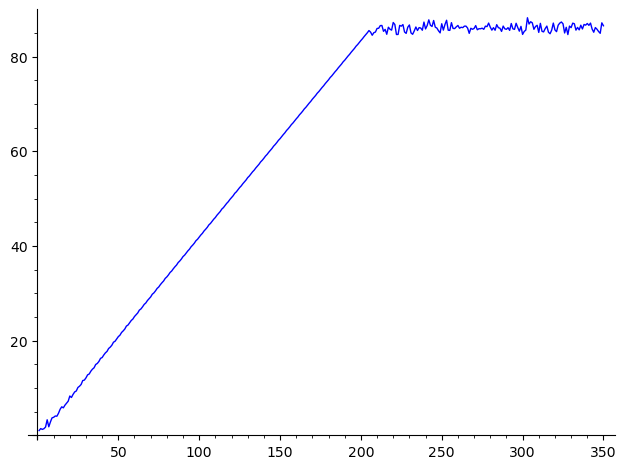

In [4]:
from sage.all import *
import pickle
import time

start=time.time()

def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return results


N=5
k=4
precision=2800 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)


indexed_list=[(n,gos[0][n]) for n in range(0,len(gos[0]))]

h_list=[pair[1] for pair in indexed_list]
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in range(1,n):
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%20==0:
        print(("j_list",n))
    





with open('/Users/barrybrent/data2/run3apr26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) #<<<<<< gos[0] bc len gos >=0
    
with open('/Users/barrybrent/data2/run3apr26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable


charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    now=time.time()
    elapsed=(now-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run3apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run3apr26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run3apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped